:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`raw_history_feature.ipynb`**!

:::


# Fit GLMs For Neural Coupling

GLMs can be used to capture pairwise interactions (couplings) between simultaneously recorded neurons. Let's see how to do this in NeMoS.

:::{admonition} Learn More

You can learn more about GLMs for pairwise interactions by following our [head direction](head-direction-tutorial) tutorial.
:::

(fully_coupled_glm_how_to)=
## Setting up a Fully Coupled GLM

### Raw Spike History as a Feature

We will start by learning how to model the pairwise interaction using the raw spike history. Let's first generate some
population counts.

In [1]:
import numpy as np
import nemos as nmo
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 100
n_neurons = 4

# generate population counts
counts = np.random.poisson(size=(n_samples, n_neurons))

Let's use the `HistoryConv` basis to construct a feature matrix capturing the effect of 10 samples of spiking history.

Shape of the feature matrix:  (100, 40)


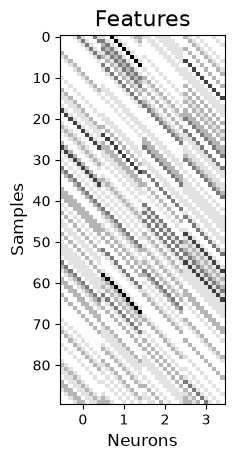

In [2]:
basis = nmo.basis.HistoryConv(window_size=10, label="spike-history")

X = basis.compute_features(counts)
print("Shape of the feature matrix: ", X.shape)

# visualize the output (skip the first window_size of nans)
plt.title("Features", fontsize=16)
plt.imshow(X[10:], cmap="Greys")
plt.xticks([5, 15, 25, 35], [0, 1, 2, 3])
plt.xlabel("Neurons", fontsize=12)
plt.ylabel("Samples", fontsize=12)
plt.show()

This is all you need to fit a fully coupled GLM.

In [3]:
model = nmo.glm.PopulationGLM().fit(X, counts)

model.coef_

Array([[ 0.14058839, -0.18125387, -0.23793788,  0.13600048],
       [-0.30337015, -0.18093988, -0.06982725,  0.06616363],
       [-0.3502828 ,  0.04838367,  0.28957605,  0.14437462],
       [-0.03178382,  0.17398058,  0.16016975, -0.0250651 ],
       [-0.27160445, -0.0124528 , -0.11089299, -0.0520212 ],
       [-0.02467203, -0.14306962,  0.15977815, -0.09243432],
       [-0.09100017, -0.01453988, -0.11158259, -0.06968804],
       [-0.01663967,  0.02326716, -0.0775822 , -0.34681225],
       [-0.03454204,  0.2246048 ,  0.10230294, -0.09805194],
       [-0.29126915,  0.2393471 , -0.20105492, -0.01817882],
       [ 0.0454983 , -0.06525086, -0.22479494,  0.00166911],
       [ 0.11086898, -0.04526146, -0.09178028, -0.07731611],
       [-0.10422681,  0.19779636,  0.16136143, -0.12839536],
       [-0.24658182,  0.06187661, -0.17482342,  0.07914896],
       [-0.15939209,  0.1780597 ,  0.0008244 ,  0.2150493 ],
       [ 0.16261439, -0.10514293, -0.05821082,  0.04835982],
       [-0.3713662 , -0.

### Reducing Dimensionality With Basis

Alternatively, one can use basis to reduce the number of parameters (useful when you have a history filter the spans hundreds of samples).
Reducing the dimensionality of the features helps to prevent overfitting and speeds up computation, particularly for long history windows.

Shape of the feature matrix:  (100, 12)


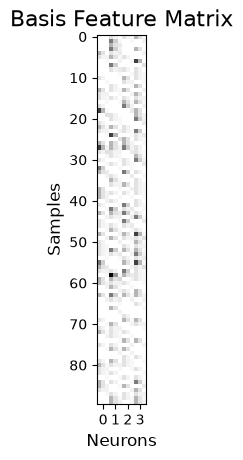

In [4]:
raised_cos = nmo.basis.RaisedCosineLogConv(3, window_size=3)

X2 = raised_cos.compute_features(counts)

# 12 Features: 3 basis funcs x 4 neurons
print("Shape of the feature matrix: ", X2.shape)

plt.title("Basis Feature Matrix", fontsize=16)
plt.imshow(X2[10:], cmap="Greys")
plt.xticks([1, 4, 7, 10], [0, 1, 2, 3])
plt.xlabel("Neurons", fontsize=12)
plt.ylabel("Samples", fontsize=12)
plt.show()

This model can be fit with the usual `model_reduced = nmo.glm.PopulationGLM().fit(X2, counts)`.

## Interpreting the coefficients

The learned model coefficients are stored in a 2D array of shape `(n_features, n_neurons)`. This array concatenates the coefficients representing pairwise couplings along the first dimension. Using the `split_by_feature` method of the basis object, the coefficients can be reshaped into a 3D array of shape `(n_neurons, n_basis_funcs, n_neurons)`, where the first dimension corresponds to sender neurons, the second dimension contains the basis function coefficients, and the third dimension corresponds to receiver neurons.

In [5]:
# get the dictionary (1 key per basis component, here there is single basis component)
split_coef = basis.split_by_feature(model.coef_, axis=0)

print(split_coef["spike-history"].shape)

(4, 10, 4)


This makes it easy to retrieve the coefficients capturing how the spike history of the neuron `i` affects the firing of neuron `j`,

In [6]:
sender_neuron_i = 1
receiver_neuron_j = 2

coeff_ij = split_coef["spike-history"][sender_neuron_i, :, receiver_neuron_j]

coeff_ij

Array([-0.22479494, -0.09178028,  0.16136143, -0.17482342,  0.0008244 ,
       -0.05821082, -0.04023682, -0.2648773 , -0.10783426,  0.10570697],      dtype=float32)

## Selecting The Connectivity Map

It is also possible select which couplings we want to learn by specifying a boolean mask (a mask of 0s and 1s) of shape `(n_features, n_neurons)`. The mask will be elementwise multiplied to the coefficients, selecting which will be included in the GLM.
For instance, if `mask[i, j] == 0`, the i-th feature won't be included in the GLM fit of the `j-th` neuron.

For example, we can exclude the bi-directional coupling between neuron 0 and 1, and the directional coupling between neuron 2 (sender) and neuron 3 (receiver).

In [7]:
# initialize a neuron x neuron mask
mask = np.ones((n_neurons, n_neurons))

# remove the bi-directional coupling between 0 and 1
mask[0, 1] = 0
mask[1, 0] = 0

# remove the directional coupling from 2 to 3
mask[2, 3] = 0

# repeat over the rows by the number of basis functions
mask = np.repeat(mask, basis.n_basis_funcs, axis=0)

We are now ready to fit the GLM masking the coefficients.

In [8]:
model_with_mask = nmo.glm.PopulationGLM(feature_mask=mask).fit(X, counts)

print(model_with_mask.coef_)

[[ 0.0462901   0.         -0.23797631  0.06809488]
 [-0.27394682  0.         -0.06980769  0.14299616]
 [-0.26989478  0.          0.28952143  0.2010127 ]
 [ 0.06341231  0.          0.16010182 -0.06749901]
 [-0.06832667  0.         -0.1108281   0.08252263]
 [-0.08301172  0.          0.15974899 -0.1068718 ]
 [-0.1597236   0.         -0.11151325 -0.00047702]
 [ 0.03463068  0.         -0.07766366 -0.31701207]
 [-0.09090219  0.          0.10226782 -0.1074372 ]
 [-0.1862666   0.         -0.2011707   0.00478506]
 [ 0.          0.05498729 -0.22477801  0.03452147]
 [ 0.         -0.05265398 -0.09183101 -0.08445918]
 [ 0.          0.15173683  0.1612296  -0.09870971]
 [ 0.          0.01649727 -0.17498747  0.08635128]
 [ 0.          0.22075877  0.0008331   0.17820962]
 [ 0.         -0.08275276 -0.05824139  0.05248773]
 [ 0.         -0.03634349 -0.04018288 -0.10387478]
 [ 0.         -0.21665962 -0.2649322   0.02637705]
 [ 0.          0.06630186 -0.10776915 -0.12585326]
 [ 0.         -0.16935791  0.10

Check that the coefficient for the connection we removed, are actually null.

In [9]:
split_coef = basis.split_by_feature(model_with_mask.coef_, axis=0)["spike-history"]

# check sender=2 receiver=3
print("Coupling 2 -> 3: ", split_coef[2, :, 3], "\n")

# check that we kept the sender=3, receiver=2
print(f"Coupling 3 -> 2: ", split_coef[3, :, 2])

Coupling 2 -> 3:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] 

Coupling 3 -> 2:  [-0.11543655 -0.01877752  0.02840734 -0.00239659  0.28770214 -0.276045
  0.20617433  0.06808943  0.0083157   0.13593495]
